In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("your_data.csv")
df = df.drop(columns=["Unnamed: 0"])
#outliers removal using IQR method
#inter quartile range is sorting the data in (sorting is done in temp memory)
#ascending order and then dividing it into 4 equal parts 25%
#then we get the mid of first and third part WHY NOT Q3? 3shan de akbr data in my dataset
# and then we get the inter quartile range by subtracting
# the mid of first part from the mid of fourth part
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
is_outlier_cell = (df < lower_bound) | (df > upper_bound)
has_outlier_row = is_outlier_cell.any(axis=1)
# Keep only the rows that do NOT have outliers
df_clean = df[~has_outlier_row]

X = df_clean.drop("smoking", axis=1)
y = df_clean["smoking"]

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# x_scaled da by3ml calc ll mean w std l kol col. then value-mean/std 
#leh b3ml kda ? 3shan a7wl el data l std normal dist.
#why? lw 3nd kol el range of numbers kber el model hyshof en da more important
#w da by2ll el accuracy and make model slower 



# normal data splitting 60% train, 20% valid, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)
print("Test size:", X_test.shape)

Train size: (78843, 10)
Valid size: (26281, 10)
Test size: (26281, 10)


In [4]:
def build_model(neurons=64, dropout_rate=0.3, learning_rate=0.001):
    #sequential de zy el pipeline 
    model = keras.Sequential([
        #dense is to make it FC 
        layers.Dense(neurons, activation='relu', 
                    input_shape=(X_train.shape[1],)),
        layers.Dropout(dropout_rate),  
        
        layers.Dense(neurons // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        #1 as o/p is smoker or not smoker 
        #sigmoid 3shan a7wl el o/p l prob between 0 and 1
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
    

In [5]:
# Build basic model
model = build_model()

# Show model structure
model.summary()

# Train it
history = model.fit(
    X_train, y_train,
    epochs=30,                        # how many times to go through data
    batch_size=32,                    # how many samples per update
    validation_data=(X_valid, y_valid),  # watch performance on valid set
    verbose=1
)

c:\Users\alaae\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6936 - loss: 0.5777 - val_accuracy: 0.7042 - val_loss: 0.5627
Epoch 2/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7025 - loss: 0.5663 - val_accuracy: 0.7064 - val_loss: 0.5609
Epoch 3/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7066 - loss: 0.5623 - val_accuracy: 0.7083 - val_loss: 0.5571
Epoch 4/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7060 - loss: 0.5618 - val_accuracy: 0.7094 - val_loss: 0.5564
Epoch 5/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7080 - loss: 0.5592 - val_accuracy: 0.7080 - val_loss: 0.5570
Epoch 6/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7102 - loss: 0.5592 - val_accuracy: 0.7094 - val_loss: 0.5544
Epoch 7/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7089 - loss: 0.5580 - val_accuracy: 0.7102 - val_loss: 0.5552
Epoch 8/30
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7095 - loss: 0.5572 - 

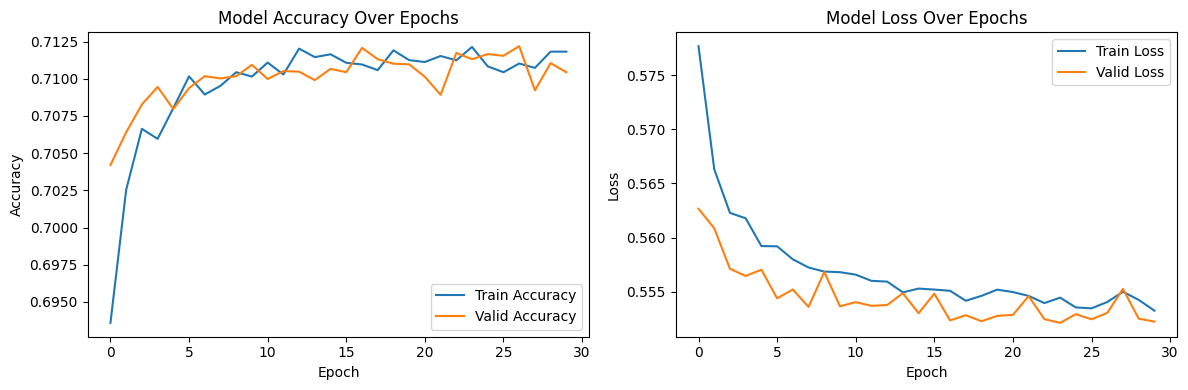

In [6]:
# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Valid Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

822/822 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Neural Network Results ===
Accuracy: 0.7120353106807199
Precision: 0.6525547445255474
Recall: 0.6833018613434043
F1-score: 0.6675744531318633


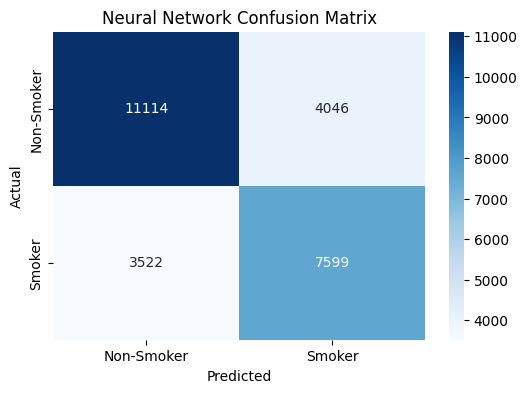

In [7]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Print metrics
print("=== Neural Network Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Smoker','Smoker'],
            yticklabels=['Non-Smoker','Smoker'])
plt.title('Neural Network Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:


from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

# Use the best parameters found
# Create a wrapper for the keras model
keras_model = KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=0)

# Define hyperparameter grid
param_grid = {
    'model__neurons': [32, 64, 128],
    'model__dropout_rate': [0.2, 0.3, 0.5],
    'model__learning_rate': [0.001, 0.01]
}

# Perform grid search
grid_search = GridSearchCV(keras_model, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

final_model = build_model(
    neurons=best_params['model__neurons'],
    dropout_rate=best_params['model__dropout_rate'],
    learning_rate=best_params['model__learning_rate']
)

# Train final model
history_final = final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

# Evaluate on test set
y_pred_final = (final_model.predict(X_test) > 0.5).astype(int).flatten()

print("=== Final Tuned Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1-score:", f1_score(y_test, y_pred_final))

c:\Users\alaae\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


c:\Users\alaae\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2464/2464 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6966 - loss: 0.5720 - val_accuracy: 0.7050 - val_loss: 0.5609
Epoch 2/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7047 - loss: 0.5630 - val_accuracy: 0.7071 - val_loss: 0.5582
Epoch 3/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7066 - loss: 0.5600 - val_accuracy: 0.7062 - val_loss: 0.5580
Epoch 4/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7079 - loss: 0.5582 - val_accuracy: 0.7085 - val_loss: 0.5552
Epoch 5/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7084 - loss: 0.5575 - val_accuracy: 0.7082 - val_loss: 0.5541
Epoch 6/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7105 - loss: 0.5548 - val_accuracy: 0.7096 - val_loss: 0.5541
Epoch 7/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7104 - loss: 0.5546 - val_accuracy: 0.7111 - val_loss: 0.5527
Epoch 8/50
2464/2464 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7108 - loss: 0.5542 - val_accurac

In [9]:
results = pd.DataFrame({
    'Model': ['Neural Network (Basic)', 'Neural Network (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_final)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_final)
    ]
})
print(results)


                    Model  Accuracy  F1-Score
0  Neural Network (Basic)  0.712035  0.667574
1  Neural Network (Tuned)  0.711883  0.674014
